# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset
from keras.src.callbacks import early_stopping
from seaborn import reset_defaults

/Users/nur/code/ml/projects/deep-mood/ml/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Dataset

In [2]:
ds = load_dataset("dair-ai/emotion")

In [3]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [4]:
train_text = ds['train']['text']
train_label = ds['train']['label']

test_text = ds['test']['text']
test_label = ds['test']['label']

In [5]:
label_name = ds['train'].features['label'].names

In [6]:
train_label

Column([0, 0, 3, 2, 3, ...])

In [7]:
label_name

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [8]:
train_label

Column([0, 0, 3, 2, 3, ...])

In [9]:
for i in train_label:
    print(label_name[i])

sadness
sadness
anger
love
anger
sadness
surprise
fear
joy
love
sadness
joy
anger
sadness
joy
joy
sadness
sadness
sadness
fear
anger
fear
joy
joy
anger
sadness
sadness
sadness
anger
joy
joy
fear
surprise
anger
joy
joy
joy
joy
anger
joy
joy
joy
joy
joy
sadness
sadness
joy
love
joy
anger
joy
sadness
anger
fear
joy
sadness
sadness
surprise
joy
joy
joy
love
fear
fear
surprise
anger
anger
sadness
love
joy
sadness
sadness
joy
sadness
sadness
sadness
joy
joy
joy
anger
sadness
anger
anger
anger
joy
joy
joy
joy
sadness
fear
love
anger
sadness
anger
love
sadness
joy
joy
sadness
anger
love
joy
joy
joy
sadness
joy
joy
joy
joy
sadness
joy
joy
love
sadness
sadness
joy
joy
sadness
joy
joy
fear
fear
fear
sadness
love
joy
joy
love
fear
surprise
joy
joy
joy
joy
anger
fear
joy
anger
love
anger
sadness
joy
sadness
anger
joy
surprise
sadness
anger
anger
sadness
joy
fear
joy
joy
fear
sadness
surprise
surprise
joy
anger
fear
anger
sadness
anger
sadness
fear
sadness
joy
surprise
fear
joy
anger
joy
anger
joy
f

In [10]:
df_train = pd.DataFrame(
    {
        'text': train_text,
        'label': [label_name[i] for i in train_label],
    }
)

df_test = pd.DataFrame(
    {
        'text': test_text,
        'label': [label_name[i] for i in test_label],
    }
)

In [11]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [12]:
df_train.isnull()

,text,label
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
15995,False,False
15996,False,False
15997,False,False
15998,False,False


# EDA

In [13]:
df_train['label'].value_counts()

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

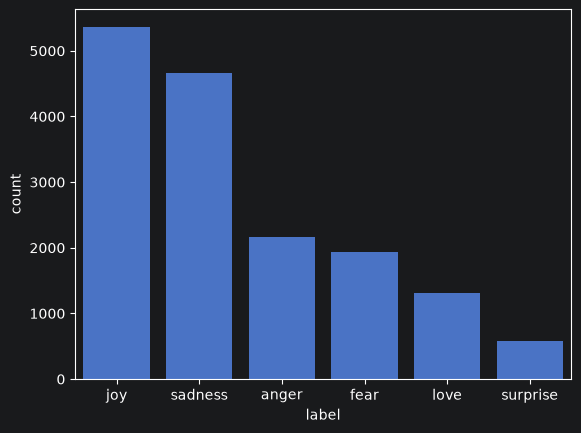

In [14]:
sns.countplot(x=df_train['label'],order=df_train['label'].value_counts().index)

# Data Preprocessing

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

In [16]:
padded_train_sequence = pad_sequences(train_sequence, maxlen=50, padding='post',truncating='post')
padded_test_sequence = pad_sequences(test_sequence, maxlen=50, padding='post',truncating='post')

In [17]:
padded_train_sequence

array([[   2,  139,    3, ...,    0,    0,    0],
       [   2,   40,  101, ...,    0,    0,    0],
       [  17, 3060,    7, ...,    0,    0,    0],
       ...,
       [   2,    3,  327, ...,    0,    0,    0],
       [   2,    3,   14, ...,    0,    0,    0],
       [   2,   47,    7, ...,    0,    0,    0]],
      shape=(16000, 50), dtype=int32)

In [18]:
train_labels = np.array(train_label)
train_labels

array([0, 0, 3, ..., 1, 3, 0], shape=(16000,))

In [19]:
test_labels = np.array(test_label)
test_labels

array([0, 0, 0, ..., 1, 1, 4], shape=(2000,))

In [20]:
num_classes = len(np.unique(train_label))
num_classes

6

In [21]:
print(f'Vocabulary size: {len(tokenizer.word_counts)}')
print(f'Max sequence length: {padded_train_sequence.shape[1]}')

Vocabulary size: 15212
Max sequence length: 50


# Shared Training Utilities

In [22]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_label),
    y=train_labels
)

class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
)

# Foundational Models

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, LSTM, GRU, Dense, Dropout

rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=120, input_length=100),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax'),
])

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

/Users/nur/code/ml/projects/deep-mood/ml/.venv/lib/python3.14/site-packages/keras/src/layers/core/embedding.py:119: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [25]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.1597 - loss: 2.0198 - val_accuracy: 0.2020 - val_loss: 1.8010
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1535 - loss: 1.8827 - val_accuracy: 0.2670 - val_loss: 1.7653
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1344 - loss: 1.8283 - val_accuracy: 0.2695 - val_loss: 1.7635
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.1347 - loss: 1.8057 - val_accuracy: 0.2730 - val_loss: 1.7738
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1354 - loss: 1.8005 - val_accuracy: 0.2625 - val_loss: 1.7762
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.1395 - loss: 1.8007 - val_accuracy: 0.2735 - val_loss: 1.7799


In [26]:
rnn_loss, rnn_acc = rnn_model.evaluate(padded_test_sequence, test_labels)

print(f'Simple RNN model loss: {rnn_loss}')
print(f'Simple RNN model accuracy: {rnn_acc}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2695 - loss: 1.7635 
Simple RNN model loss: 1.7634761333465576
Simple RNN model accuracy: 0.2694999873638153


# Standard LSTM

In [27]:
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=120, input_length=100),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax'),
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

/Users/nur/code/ml/projects/deep-mood/ml/.venv/lib/python3.14/site-packages/keras/src/layers/core/embedding.py:119: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [28]:
lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 47ms/step - accuracy: 0.1584 - loss: 1.7951 - val_accuracy: 0.2880 - val_loss: 1.7963
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.1577 - loss: 1.7937 - val_accuracy: 0.1135 - val_loss: 1.7853
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.1651 - loss: 1.7929 - val_accuracy: 0.2530 - val_loss: 1.7860
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.1734 - loss: 1.7848 - val_accuracy: 0.1130 - val_loss: 1.7886
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.1844 - loss: 1.7753 - val_accuracy: 0.0655 - val_loss: 1.8082


In [29]:
lstm_loss, lstm_acc = lstm_model.evaluate(padded_test_sequence, test_labels)

print(f'LSTM model loss: {lstm_loss}')
print(f'LSTM model accuracy: {lstm_acc}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1135 - loss: 1.7853
LSTM model loss: 1.7852673530578613
LSTM model accuracy: 0.11349999904632568


# Standard GRU

In [30]:
gru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=120, input_length=100),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax'),
])

gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

/Users/nur/code/ml/projects/deep-mood/ml/.venv/lib/python3.14/site-packages/keras/src/layers/core/embedding.py:119: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [31]:
gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.1599 - loss: 1.7969 - val_accuracy: 0.2905 - val_loss: 1.7867
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.1634 - loss: 1.7952 - val_accuracy: 0.1170 - val_loss: 1.7937
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.1527 - loss: 1.7946 - val_accuracy: 0.2880 - val_loss: 1.7936
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.1680 - loss: 1.7933 - val_accuracy: 0.1185 - val_loss: 1.7842
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.1714 - loss: 1.7900 - val_accuracy: 0.1150 - val_loss: 1.7919
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.1787 - loss: 1.7774 - val_accuracy: 0.2005 - val_loss: 1.7958
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.2176 - loss: 1.7487 - val_accuracy: 0.2655 - val_loss: 1.7754
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.2269 - loss: 1.6990 - 

In [32]:
gru_loss, gru_acc = gru_model.evaluate(padded_test_sequence, test_labels)

print(f'GRU model loss: {gru_loss}')
print(f'GRU model accuracy: {gru_acc}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2655 - loss: 1.7754 
GRU model loss: 1.7754478454589844
GRU model accuracy: 0.265500009059906


In [33]:
result_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_acc, lstm_acc, gru_acc],
}).sort_values(by='Test Accuracy', ascending=False)

In [34]:
result_df

,Model,Test Loss,Test Accuracy
0,RNN,1.763476,0.2695
2,GRU,1.775448,0.2655
1,LSTM,1.785267,0.1135


# Bidirectional GRU

In [35]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=100),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/Users/nur/code/ml/projects/deep-mood/ml/.venv/lib/python3.14/site-packages/keras/src/layers/core/embedding.py:119: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [36]:
BiGRU.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 47s 87ms/step - accuracy: 0.5959 - loss: 0.9885 - val_accuracy: 0.8950 - val_loss: 0.2778
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - accuracy: 0.9210 - loss: 0.2269 - val_accuracy: 0.9170 - val_loss: 0.2188
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 76ms/step - accuracy: 0.9467 - loss: 0.1491 - val_accuracy: 0.9085 - val_loss: 0.2736
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 81ms/step - accuracy: 0.9555 - loss: 0.1215 - val_accuracy: 0.9170 - val_loss: 0.2822
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 73ms/step - accuracy: 0.9655 - loss: 0.0904 - val_accuracy: 0.9125 - val_loss: 0.2699


In [38]:
BiGRU_loss, BiGRU_acc = BiGRU.evaluate(padded_test_sequence, test_labels)

print(f'BiGRU model loss: {BiGRU_loss}')
print(f'BiGRU model accuracy: {BiGRU_acc}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9170 - loss: 0.2188
LSTM model loss: 0.2188117802143097
LSTM model accuracy: 0.9169999957084656


# Bidirectional LSTM

In [39]:
BiLSTM = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=100),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

BiLSTM.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/Users/nur/code/ml/projects/deep-mood/ml/.venv/lib/python3.14/site-packages/keras/src/layers/core/embedding.py:119: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [40]:
BiLSTM.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
BiLSTM.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 68ms/step - accuracy: 0.5664 - loss: 1.0400 - val_accuracy: 0.8855 - val_loss: 0.3397
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 0.9167 - loss: 0.2423 - val_accuracy: 0.9190 - val_loss: 0.2099
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.9426 - loss: 0.1553 - val_accuracy: 0.9125 - val_loss: 0.2481
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 88ms/step - accuracy: 0.9556 - loss: 0.1205 - val_accuracy: 0.9170 - val_loss: 0.2305
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - accuracy: 0.9680 - loss: 0.0892 - val_accuracy: 0.9065 - val_loss: 0.2784


In [42]:
BiLSTM_loss, BiLSTM_acc = BiLSTM.evaluate(padded_test_sequence, test_labels)

print(f'BiLSTM model loss: {BiLSTM_loss}')
print(f'BiLSTM model accuracy: {BiLSTM_acc}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9190 - loss: 0.2099
LSTM model loss: 0.20989400148391724
LSTM model accuracy: 0.9190000295639038


# Result

In [43]:
result_df.loc[len(result_df)] = ["BiGRU", BiGRU_loss, BiGRU_acc]
result_df.loc[len(result_df)] = ["BiLSTM", BiLSTM_loss, BiLSTM_acc]

In [44]:
result_df.sort_values(by='Test Accuracy', ascending=False)

,Model,Test Loss,Test Accuracy
4,BiLSTM,0.209894,0.9190
3,BiGRU,0.218812,0.9170
0,RNN,1.763476,0.2695
2,GRU,1.775448,0.2655
1,LSTM,1.785267,0.1135


# Evaluation

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step  


<Axes: >

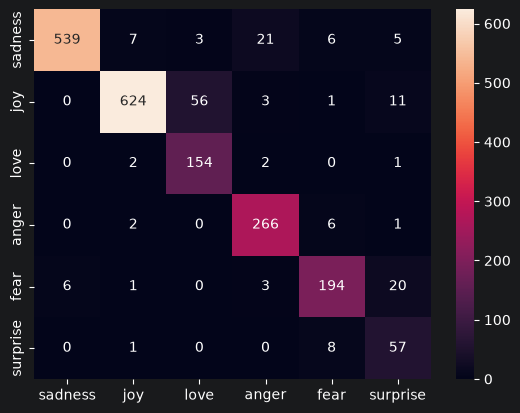

In [45]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence), axis=1)

sns.heatmap(confusion_matrix(test_labels, BiGRU_predictions), annot=True, fmt="d", xticklabels=label_name, yticklabels=label_name)

# Final Predictions

In [46]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
    print(f'sample text: {sample_texts[i]}')
    print(f'sample prediction: {label_name[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
sample text: I can't believe how happy I am right now, this is amazing!
sample prediction: joy
sample text: I feel so alone and hopeless today.
sample prediction: sadness
sample text: I am furious that they cancelled the trip at the last minute.
sample prediction: anger
sample text: I feel terrified when walking down dark alleyways alone.
sample prediction: fear
sample text: I was shocked and completely surprised by the unexpected gift!
sample prediction: surprise


# Save Model & Tokenizer

In [49]:
import os
import pickle

model_dir = '../artifacts'
os.makedirs(model_dir, exist_ok=True)

BiGRU.save(os.path.join(model_dir, 'BiGRU_model.keras'))
BiLSTM.save(os.path.join(model_dir, 'BiLSTM_model.keras'))

with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
    pickle.dump(tokenizer, file)